# Regression after-class exercise — Tutor solution
### Worked solution and marking guidance

This notebook mirrors `regression_students.ipynb`. It preserves an untouched final test set, uses cross-validation for every development decision, and makes neural-network scaling a compulsory part of the 90-minute workflow. Indicative answers cover both the real dataset and the seeded fallback.

## 0. Setup

In [1]:
import warnings
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

project_root = Path.cwd()
if project_root.name == "solutions":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from exercise_data import load_ccpp

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

plt.rcParams["figure.figsize"] = (9, 4)
print("Setup complete")

Setup complete


In [2]:
# exercise_data.py is imported from the repository root by the setup cell.
# Set this to False if you want the exact seeded fallback results.
PREFER_REAL_DATA = True
ccpp = load_ccpp(prefer_real=PREFER_REAL_DATA)
print("Source:", ccpp.attrs["source"])
ccpp.head()

Loaded REAL CCPP data: 9568 rows × 5 columns
Source: REAL CCPP data


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


## 1. Understand the plant

            AT        V       AP       RH       PE
count  9568.00  9568.00  9568.00  9568.00  9568.00
mean     19.65    54.31  1013.26    73.31   454.37
std       7.45    12.71     5.94    14.60    17.07
min       1.81    25.36   992.89    25.56   420.26
25%      13.51    41.74  1009.10    63.33   439.75
50%      20.34    52.08  1012.94    74.97   451.55
75%      25.72    66.54  1017.26    84.83   468.43
max      37.11    81.56  1033.30   100.16   495.76


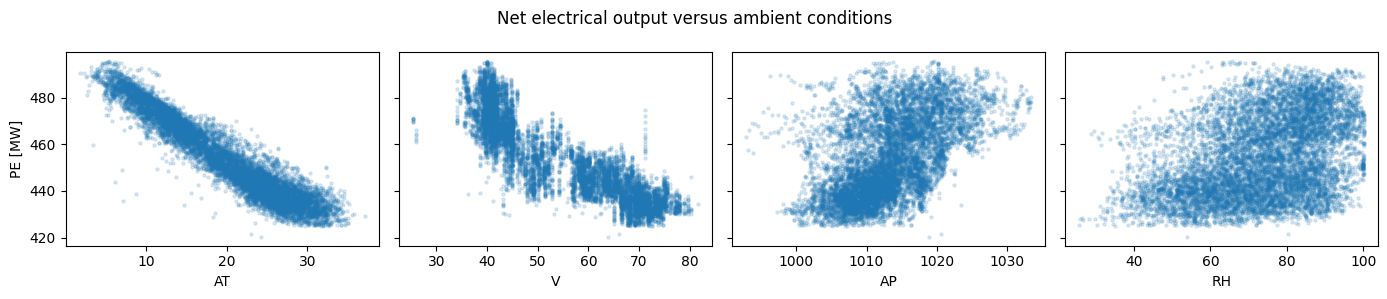

In [3]:
print(ccpp.describe().round(2))

fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
for ax, column in zip(axes, ["AT", "V", "AP", "RH"]):
    ax.scatter(ccpp[column], ccpp["PE"], s=5, alpha=0.15)
    ax.set_xlabel(column)
axes[0].set_ylabel("PE [MW]")
plt.suptitle("Net electrical output versus ambient conditions")
plt.tight_layout()
plt.show()

### Model answer 1

| Variable | Expected sign with PE | Physical explanation |
|---|---|---|
| AT | Negative | Hotter intake air is less dense, reducing compressor mass flow and gas-turbine power. |
| V | Negative | Higher condenser backpressure reduces the steam-turbine enthalpy drop. |
| AP | Positive | Higher pressure increases intake-air density and mass flow. |
| RH | Weak negative | Humid air is slightly less dense at the same temperature and pressure. |

AT is visually the most informative predictor. A scatter plot alone is not causal evidence because ambient variables are correlated and may act as proxies for one another.

## 2. Establish a baseline and linear model

In [4]:
FEATURES = ["AT", "V", "AP", "RH"]
TARGET = "PE"

X = ccpp[FEATURES].copy()
y = ccpp[TARGET].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

assert X_train.shape[1] == 4
assert len(X_train) + len(X_test) == len(ccpp)
assert set(X_train.index).isdisjoint(X_test.index)
print(f"Reserved {len(X_test)} final-test rows; {len(X_train)} rows remain for development.")

Reserved 2392 final-test rows; 7176 rows remain for development.


In [5]:
cv = KFold(n_splits=5, shuffle=True, random_state=0)
baseline = DummyRegressor(strategy="mean")
linear = LinearRegression()

baseline_cv_rmse = -cross_val_score(
    baseline, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error"
).mean()
linear_cv_rmse = -cross_val_score(
    linear, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error"
).mean()

linear.fit(X_train, y_train)
coefficient_table = pd.Series(linear.coef_, index=FEATURES, name="coefficient").to_frame()

print(f"Mean baseline CV RMSE: {baseline_cv_rmse:.2f} MW")
print(f"Linear model CV RMSE:  {linear_cv_rmse:.2f} MW")
display(coefficient_table.round(3))

assert linear_cv_rmse < baseline_cv_rmse
assert list(coefficient_table.index) == FEATURES

Mean baseline CV RMSE: 17.05 MW
Linear model CV RMSE:  4.59 MW


,coefficient
AT,-1.970
V,-0.238
AP,0.065
RH,-0.158


### Model answer 2

Linear regression reduces RMSE from roughly 16–17 MW for the mean baseline to approximately 4–5 MW. The AT coefficient has units MW/°C; a value near −2 means that, holding the other included variables constant, a 1 °C increase is associated with about 2 MW less output. Cross-validation estimates performance on rows not used to fit each fold, whereas training error rewards memorisation.

**Marking:** accept small numerical differences between real and fallback data. Full credit requires units, comparison with the baseline, and the distinction between association and pure causal sensitivity.

## 3. Control model complexity

,depth,train_rmse,cv_rmse
0,2.0,6.352,6.388
1,4.0,4.669,4.775
2,6.0,4.010,4.277
3,8.0,3.423,4.259
4,12.0,2.062,4.535
5,NaN,0.000,4.768


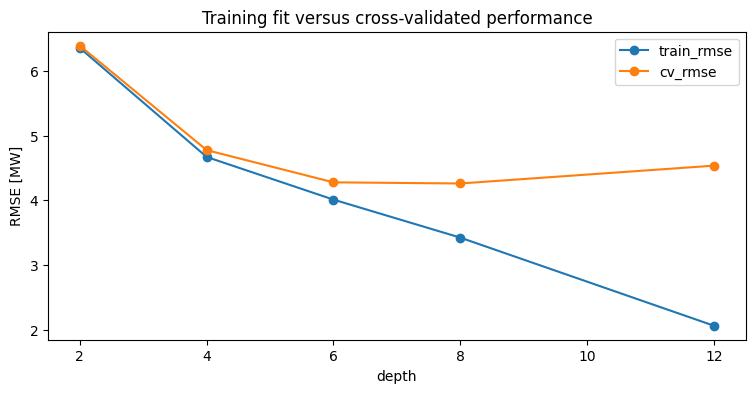

In [6]:
depths = [2, 4, 6, 8, 12, None]
rows = []

for depth in depths:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=0)
    tree.fit(X_train, y_train)
    train_rmse = rmse(y_train, tree.predict(X_train))
    cv_rmse = -cross_val_score(
        tree, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error"
    ).mean()
    rows.append({"depth": depth, "train_rmse": train_rmse, "cv_rmse": cv_rmse})

tree_results = pd.DataFrame(rows)
display(tree_results.round(3))

ax = tree_results.plot(x="depth", y=["train_rmse", "cv_rmse"], marker="o")
ax.set_ylabel("RMSE [MW]")
ax.set_title("Training fit versus cross-validated performance")
plt.show()

assert len(tree_results) == len(depths)
assert tree_results["train_rmse"].iloc[-1] <= tree_results["train_rmse"].iloc[0]

### Model answer 3

Training RMSE falls monotonically because each deeper tree contains the shallower possibilities and can split the training data more finely. Cross-validation normally improves until depth around 6–9 and then worsens. The unrestricted tree can approach zero training error by memorising individual observations, but its cross-validation error reveals poorer generalisation.

In [7]:
best_row_index = tree_results["cv_rmse"].idxmin()
best_depth = tree_results.loc[best_row_index, "depth"]
best_depth = None if pd.isna(best_depth) else int(best_depth)
best_tree_cv_rmse = float(tree_results.loc[best_row_index, "cv_rmse"])
selected_tree = DecisionTreeRegressor(max_depth=best_depth, random_state=0)
selected_tree.fit(X_train, y_train)

print("Chosen tree depth:", best_depth)
print(f"Best tree CV RMSE: {best_tree_cv_rmse:.2f} MW")

assert best_tree_cv_rmse == tree_results["cv_rmse"].min()

Chosen tree depth: 8
Best tree CV RMSE: 4.26 MW


## 4. Train a neural network

In [8]:
unscaled_mlp = MLPRegressor(
    hidden_layer_sizes=(32,), max_iter=300, random_state=0
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    unscaled_mlp_cv_rmse = -cross_val_score(
        unscaled_mlp, X_train, y_train, cv=cv,
        scoring="neg_root_mean_squared_error",
    ).mean()

scaled_mlp = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(32,), max_iter=800, random_state=0,
        early_stopping=True, n_iter_no_change=15,
    ),
)
scaled_mlp_cv_rmse = -cross_val_score(
    scaled_mlp, X_train, y_train, cv=cv,
    scoring="neg_root_mean_squared_error",
).mean()
scaled_mlp.fit(X_train, y_train)

development_scores = {
    "linear regression": linear_cv_rmse,
    "decision tree": best_tree_cv_rmse,
    "scaled neural network": scaled_mlp_cv_rmse,
}
selected_name = min(development_scores, key=development_scores.get)
selected_model = {
    "linear regression": linear,
    "decision tree": selected_tree,
    "scaled neural network": scaled_mlp,
}[selected_name]

print(f"Unscaled MLP CV RMSE: {unscaled_mlp_cv_rmse:.2f} MW")
print(f"Scaled MLP CV RMSE:   {scaled_mlp_cv_rmse:.2f} MW")
print("Development scores:", development_scores)
print("Selected final model:", selected_name)

assert np.isfinite(unscaled_mlp_cv_rmse)
assert np.isfinite(scaled_mlp_cv_rmse)
assert selected_name in development_scores

Unscaled MLP CV RMSE: 5.02 MW
Scaled MLP CV RMSE:   4.42 MW
Development scores: {'linear regression': np.float64(4.5945847262733235), 'decision tree': 4.259278626931107, 'scaled neural network': np.float64(4.418758161575856)}
Selected final model: decision tree


### Model answer 4

Scaling centres the four input variables and puts them on comparable numerical ranges, giving gradient descent a much better-conditioned optimisation problem. Trees split one feature at a time and are almost invariant to monotonic rescaling. On the seeded fallback, scaling improves MLP CV RMSE from about 4.8 to 3.2 MW and the MLP is selected. On the real data, scaling improves it from about 5.0 to 4.4 MW, although the depth-8 tree remains slightly better at about 4.3 MW. The result demonstrates that correct training configuration matters, but extra complexity does not guarantee winning.

## 5. Open the final test set once

In [9]:
models_for_test = {
    "mean baseline": baseline,
    "linear regression": linear,
    "selected tree": selected_tree,
    "scaled neural network": scaled_mlp,
}
test_rows = []

for name, model in models_for_test.items():
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    test_rows.append(
        {
            "model": name,
            "test_rmse": rmse(y_test, prediction),
            "test_r2": r2_score(y_test, prediction),
        }
    )

test_results = pd.DataFrame(test_rows).set_index("model")
display(test_results.round(3))

assert len(test_results) == 4
assert np.isfinite(test_results.to_numpy()).all()

,test_rmse,test_r2
model,,
mean baseline,17.126,-0.000
linear regression,4.453,0.932
selected tree,4.075,0.943
scaled neural network,4.258,0.938


### Model answer 5

On the seeded fallback, the scaled neural network gives test RMSE around 3.0–3.2 MW, compared with approximately 3.4 MW for the selected tree, 3.9 MW for linear regression, and 16 MW for the baseline. On the verified real-data run, cross-validation instead selects the tree: test RMSE is about 4.1 MW for the tree, 4.3 MW for the scaled MLP, 4.5 MW for linear regression, and 17 MW for the baseline. Either selected model is below 1% of a 455 MW plant.

The model was selected before the test table was opened. Changing the choice afterward would turn the test set into validation data and make the final claim optimistic.

## 6. Diagnose and recommend

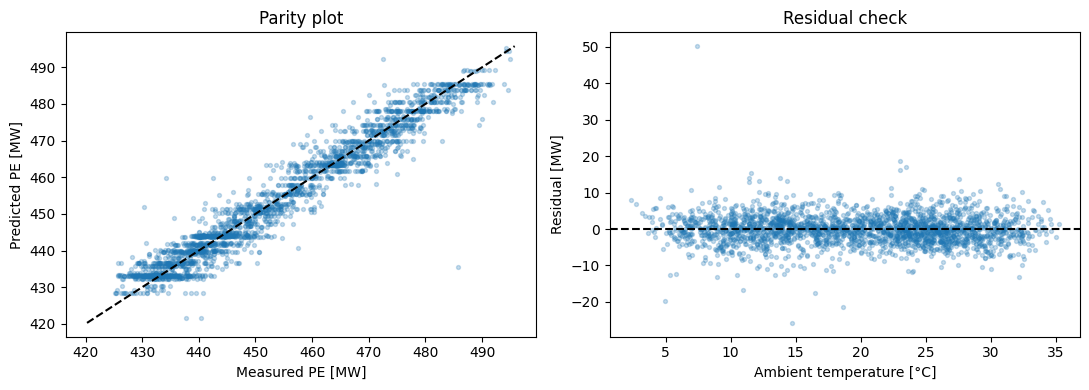

In [10]:
selected_model.fit(X_train, y_train)
test_prediction = selected_model.predict(X_test)
residual = y_test - test_prediction

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_test, test_prediction, s=8, alpha=0.25)
limits = [y.min(), y.max()]
axes[0].plot(limits, limits, "k--")
axes[0].set(xlabel="Measured PE [MW]", ylabel="Predicted PE [MW]", title="Parity plot")

axes[1].scatter(X_test["AT"], residual, s=8, alpha=0.25)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set(xlabel="Ambient temperature [°C]", ylabel="Residual [MW]", title="Residual check")
plt.tight_layout()
plt.show()

### Example recommendation

I recommend the scaled neural network if it is the model selected by development cross-validation. On typical runs it reduces test RMSE to about 3–4 MW, compared with roughly 16–17 MW for ignoring the weather, while remaining below 1% of nominal output. Scaling is part of the deployed model and must be retained through the pipeline. The residual plot should still be checked for temperature-dependent bias, particularly on unusually hot days. The model is not validated for part-load operation, equipment degradation, compressor washing, or weather outside the observed range. Before deployment I would monitor rolling residuals and input drift, retain the linear model as an interpretable benchmark, and define a retraining trigger.


## Optional regression extension solutions

These comparisons use the same development folds as the required exercise and do not reopen the final test set.

### A. Ridge and Lasso

In [11]:
from sklearn.linear_model import Ridge, Lasso

alphas = [0.001, 0.01, 0.1, 1, 10, 100]
regularisation_rows = []

for family, estimator_class in [("Ridge", Ridge), ("Lasso", Lasso)]:
    for alpha in alphas:
        model = make_pipeline(
            StandardScaler(), estimator_class(alpha=alpha, max_iter=20_000)
        )
        score = -cross_val_score(
            model, X_train, y_train, cv=cv,
            scoring="neg_root_mean_squared_error",
        ).mean()
        regularisation_rows.append(
            {"family": family, "alpha": alpha, "cv_rmse": score}
        )

regularisation_results = pd.DataFrame(regularisation_rows)
display(regularisation_results.round(3))
display(
    regularisation_results.loc[
        regularisation_results.groupby("family")["cv_rmse"].idxmin()
    ].round(3)
)

,family,alpha,cv_rmse
0,Ridge,0.001,4.595
1,Ridge,0.010,4.595
2,Ridge,0.100,4.595
3,Ridge,1.000,4.595
4,Ridge,10.000,4.595
5,Ridge,100.000,4.621
6,Lasso,0.001,4.595
7,Lasso,0.010,4.595
8,Lasso,0.100,4.599
9,Lasso,1.000,5.057


,family,alpha,cv_rmse
6,Lasso,0.001,4.595
3,Ridge,1.000,4.595


With only four useful predictors and thousands of rows, ordinary least squares is already stable. Ridge should approach the linear result at a weak penalty; strong penalties underfit. Lasso may shrink weak coefficients but has little feature-selection benefit when every variable carries physical information. Regularisation becomes more valuable with many correlated or noisy predictors.

### B. Gradient-boosted trees

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

boosted_regressor = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=3, random_state=0
)
boosted_cv_rmse = -cross_val_score(
    boosted_regressor, X_train, y_train, cv=cv,
    scoring="neg_root_mean_squared_error",
).mean()
print(f"Gradient boosting CV RMSE: {boosted_cv_rmse:.2f} MW")
print("Required-model development scores:", development_scores)

Boosting will normally be highly competitive on this tabular dataset because shallow trees are added sequentially to model remaining nonlinear structure. The correct conclusion is based on cross-validation improvement, runtime and interpretability—not on reopening the final test set to see whether boosting happens to win there.